# Chapter 19: Visual Perception

Source orientation: *Fundamentals of Computer Graphics*, Chapter 19, printed pages 525-568, PDF pages 542-585. The source span covers visual sensitivity, brightness and contrast, color, dynamic range, field-of-view and acuity, motion sensitivity, spatial depth cues, object recognition, event perception, visual attention, and picture perception. This notebook uses that span for scope and terminology, then builds original synthetic stimuli and computational checks.

## Chapter Goal

The goal is to make perception operational for graphics work. A renderer does not send surfaces, distances, or events to a viewer. It sends a time-varying pattern of light on a display. Human vision turns that proximal pattern into inferred lightness, color, surface layout, object identity, motion, and pictorial space. We will build small stimuli where the pixels are known and the perceptual inference can be inspected.

## Translation guide

| Perception topic | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Sensitivity and contrast | sinusoidal gratings, Weber/log/power response curves, adaptation windows | contrast threshold changes with spatial frequency and adaptation level |
| Lightness and color interactions | equal-pixel center patches placed in different surrounds | the image data can be identical where the percept differs |
| Color encoding | synthetic spectra compressed through three cone-like sensitivity curves | many spectra collapse to nearly the same cone response |
| Spatial vision | projection diagrams, vergence geometry, texture foreshortening, shadow cues | depth cues are constraints, not direct distance measurements |
| Motion perception | optic-flow fields and temporally sampled wheel motion | heading and aliasing can be computed from image motion patterns |
| Object perception | grouping displays and template matching on synthetic objects | low-level grouping and matching are distinct stages |
| Picture perception | rendered frustum compared with actual viewing geometry | a picture is geometrically correct only from a compatible viewing position |

## Library Routing

This chapter is mostly about image stimuli and visual inference, so the primary tools are `numpy`, `Pillow`, `scikit-image`, and `opencv` for synthetic image construction, filtering, color conversion, and matching. `matplotlib` is used for durable annotated figures, because the core objects are 2D retinal/display patterns. `plotly` is used for the viewing-geometry artifact where interactive comparison of viewing positions is useful. `pandas` and JSON artifacts record the numeric invariants behind the visuals.
## Visual storyboard

1. Contrast sensitivity and adaptation: generate gratings and response curves, then check threshold and Weber-style invariants.
2. Lightness and color context: hold selected pixels fixed while changing surrounds, then check gray, RGB, and Lab equality.
3. Cone compression: construct synthetic spectra with nearly equal model cone responses.
4. Spatial depth cues: connect perspective, vergence, texture, shading, shadows, and T-junctions to numeric constraints.
5. Motion perception: compare optic-flow fields with temporal aliasing under frame sampling.
6. Object perception: contrast grouping displays with an auditable template-matching search.
7. Picture perception: compare render frustum geometry with actual display viewing geometry.


In [1]:
CHAPTER = 19
TITLE = "Visual Perception"
TOPIC = f"chapter-{CHAPTER:02d}"
PRINTED_PAGES = "525-568"
PDF_PAGES = "542-585"


In [2]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
for kind in ["figures", "html", "checks", "tables", "data"]:
    (ARTIFACT_ROOT / kind).mkdir(parents=True, exist_ok=True)

ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()

'artifacts/chapter-19'

In [3]:
import json
import math

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy import optimize
from skimage import color, filters

from utils.artifacts import (
    assert_artifacts,
    book_relative,
    display_artifact,
    save_json,
    save_matplotlib,
    save_plotly_html,
    save_table_csv,
)
from utils.notebook_checks import assert_nonblank_image
from utils.plotting import PALETTE, style_axis

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 10})

figure_paths = []
html_paths = []
check_paths = []
table_paths = []
validation = {}

def remember(path, bucket):
    bucket.append(Path(path))
    return Path(path)

def save_fig(fig, filename):
    path = save_matplotlib(fig, TOPIC, filename, dpi=170)
    plt.close(fig)
    return remember(path, figure_paths)

def save_check(data, filename):
    return remember(save_json(data, TOPIC, filename), check_paths)

def save_table(rows, filename):
    return remember(save_table_csv(rows, TOPIC, filename), table_paths)

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

## 1. Sensitivity Is Pattern-Dependent

The chapter starts from a point that is easy to forget in graphics: the eye is not a photometer. It is much better at detecting spatial, temporal, and spectral structure than absolute energy. A one-level change in an 8-bit ramp can be visible in one context and invisible in another. The synthetic grating below turns that into an inspectable test.

The left panel varies spatial frequency horizontally and contrast vertically. The right panels encode three psychophysical ideas used throughout graphics: Weber-like ratios for just noticeable differences, compressive perceptual response functions, and adaptation windows that move over a huge physical luminance range.

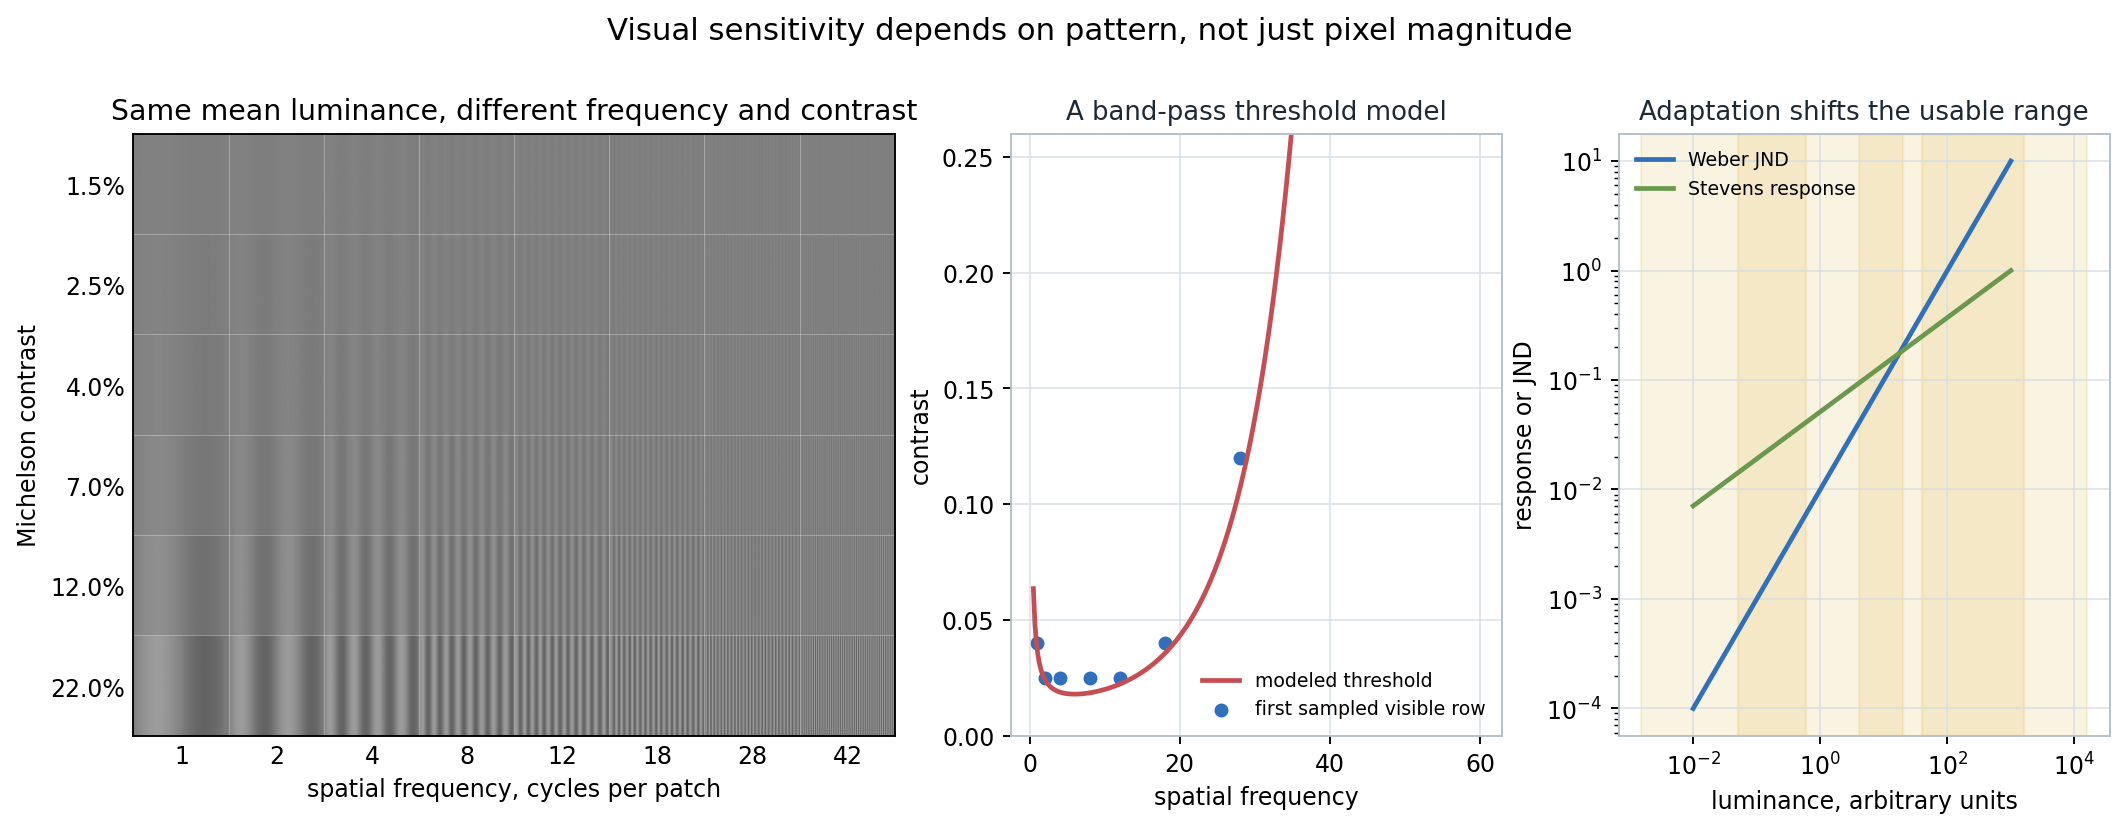

In [4]:
freqs = np.array([1, 2, 4, 8, 12, 18, 28, 42], dtype=float)
contrasts = np.array([0.015, 0.025, 0.04, 0.07, 0.12, 0.22], dtype=float)
cell_h, cell_w = 54, 88
x = np.linspace(0.0, 1.0, cell_w, endpoint=False)
grating = np.zeros((len(contrasts) * cell_h, len(freqs) * cell_w), dtype=float)
for r, contrast in enumerate(contrasts):
    for c, freq in enumerate(freqs):
        wave = 0.5 + 0.5 * contrast * np.sin(2 * np.pi * freq * x)
        grating[r * cell_h:(r + 1) * cell_h, c * cell_w:(c + 1) * cell_w] = wave

fine_freq = np.linspace(0.5, 60, 300)
peak = 6.0
sensitivity = (fine_freq / peak) * np.exp(1 - fine_freq / peak)
threshold = 0.012 / np.maximum(sensitivity, 1e-6) + 0.006
sample_sensitivity = (freqs / peak) * np.exp(1 - freqs / peak)
sample_threshold = 0.012 / np.maximum(sample_sensitivity, 1e-6) + 0.006
visibility = contrasts[:, None] / sample_threshold[None, :]

intensity = np.geomspace(0.01, 1000.0, 160)
weber_k = 0.01
weber_jnd = weber_k * intensity
fechner = np.log10(intensity / intensity.min())
stevens = intensity ** 0.43
stevens = stevens / stevens.max()
adapt_levels = np.array([0.03, 1.0, 80.0, 800.0])
adapt_windows = [(a / 20.0, a * 20.0) for a in adapt_levels]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.55, 1.0, 1.0]})
axes[0].imshow(grating, cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("Same mean luminance, different frequency and contrast")
axes[0].set_xticks(np.arange(len(freqs)) * cell_w + cell_w / 2, labels=[f"{f:g}" for f in freqs])
axes[0].set_yticks(np.arange(len(contrasts)) * cell_h + cell_h / 2, labels=[f"{100*c:.1f}%" for c in contrasts])
axes[0].set_xlabel("spatial frequency, cycles per patch")
axes[0].set_ylabel("Michelson contrast")
axes[0].tick_params(length=0)
for c in range(1, len(freqs)):
    axes[0].axvline(c * cell_w - 0.5, color="white", lw=0.35, alpha=0.35)
for r in range(1, len(contrasts)):
    axes[0].axhline(r * cell_h - 0.5, color="white", lw=0.35, alpha=0.35)

first_visible = []
for c in range(len(freqs)):
    rows = np.flatnonzero(visibility[:, c] >= 1)
    first_visible.append(contrasts[rows[0]] if len(rows) else np.nan)
axes[1].plot(fine_freq, threshold, color=PALETTE["red"], lw=2, label="modeled threshold")
axes[1].scatter(freqs, first_visible, color=PALETTE["blue"], s=24, label="first sampled visible row")
axes[1].set_ylim(0, 0.26)
style_axis(axes[1], "A band-pass threshold model", xlabel="spatial frequency", ylabel="contrast")
axes[1].legend(frameon=False, fontsize=8)

axes[2].loglog(intensity, weber_jnd, color=PALETTE["blue"], lw=2, label="Weber JND")
axes[2].semilogx(intensity, stevens, color=PALETTE["green"], lw=2, label="Stevens response")
for lo, hi in adapt_windows:
    axes[2].axvspan(lo, hi, color=PALETTE["gold"], alpha=0.12)
style_axis(axes[2], "Adaptation shifts the usable range", xlabel="luminance, arbitrary units", ylabel="response or JND")
axes[2].legend(frameon=False, fontsize=8)
fig.suptitle("Visual sensitivity depends on pattern, not just pixel magnitude", y=1.03, fontsize=13)
contrast_path = save_fig(fig, "contrast-sensitivity-adaptation-field.png")

psychophysics_rows = [
    {"intensity": float(i), "weber_jnd": float(j), "fechner_strength": float(f), "stevens_strength_normalized": float(s)}
    for i, j, f, s in zip(intensity[::8], weber_jnd[::8], fechner[::8], stevens[::8])
]
psychophysics_table = save_table(psychophysics_rows, "psychophysics-response-curves.csv")
validation["contrast_sensitivity"] = {
    "grating_mean": float(grating.mean()),
    "grating_std": float(grating.std()),
    "threshold_min_frequency": float(fine_freq[np.argmin(threshold)]),
    "weber_ratio": weber_k,
    "stevens_is_compressive": bool((np.diff(stevens) > 0).all() and stevens[len(stevens)//2] > intensity[len(intensity)//2] / intensity.max()),
    "visibility_cells_above_threshold": int((visibility >= 1).sum()),
}
contrast_checks = save_check(validation["contrast_sensitivity"], "contrast-sensitivity-checks.json")
display_artifact(contrast_path, width=900)
display_artifact(psychophysics_table)

## 2. Equal Pixels Can Support Unequal Percepts

Lightness constancy, simultaneous contrast, subjective contours, and color context are not bugs in the visual system. They are consequences of a system that estimates surfaces and illumination from ambiguous retinal data. For graphics, the practical warning is direct: checking only local RGB values is not enough to predict appearance.

The next artifact intentionally keeps some image measurements identical. The center gray patches are the same pixel value; the center color swatches are the same RGB and Lab value. The surrounds change the perceptual interpretation.

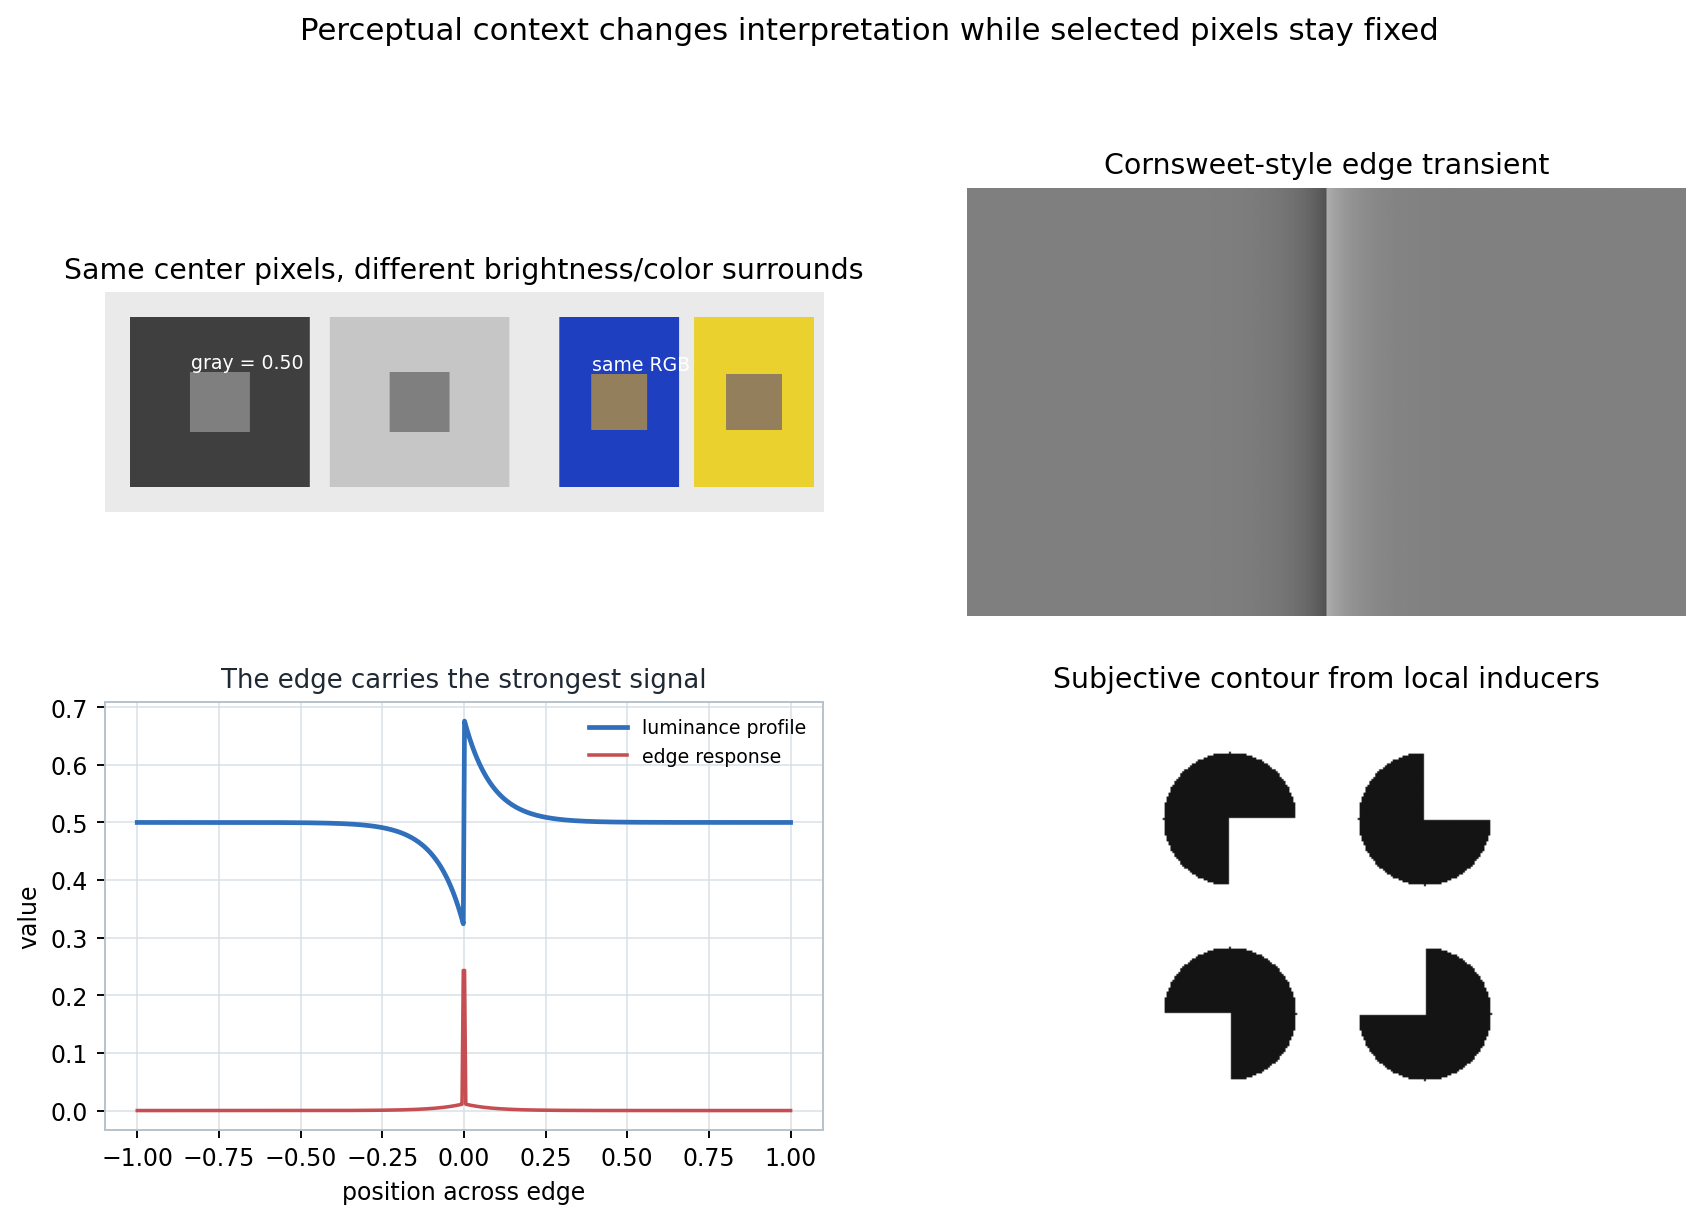

In [5]:
context = np.ones((220, 720, 3), dtype=float)
context[:] = 0.92
context[25:195, 25:205] = 0.25
context[25:195, 225:405] = 0.78
center_gray = np.array([0.50, 0.50, 0.50])
context[80:140, 85:145] = center_gray
context[80:140, 285:345] = center_gray
context[25:195, 455:575] = np.array([0.12, 0.25, 0.75])
context[25:195, 590:710] = np.array([0.92, 0.82, 0.18])
center_rgb = np.array([0.58, 0.50, 0.36])
context[82:138, 487:543] = center_rgb
context[82:138, 622:678] = center_rgb

w = 520
xx = np.linspace(-1, 1, w)
profile = 0.5 + 0.18 * np.sign(xx) * np.exp(-np.abs(xx) * 12)
cornsweet = np.tile(profile, (90, 1))
edge_grad = filters.sobel(cornsweet)

kanizsa = np.ones((220, 220), dtype=float)
yy, xx2 = np.mgrid[:220, :220]
from skimage.draw import polygon as ski_polygon
for cy, cx, angle in [(60, 60, 45), (160, 60, 135), (60, 160, -45), (160, 160, -135)]:
    disk = (xx2 - cx) ** 2 + (yy - cy) ** 2 <= 34 ** 2
    kanizsa[disk] = 0.08
    theta1 = math.radians(angle - 45)
    theta2 = math.radians(angle + 45)
    p0 = np.array([cx, cy])
    p1 = p0 + 48 * np.array([math.cos(theta1), math.sin(theta1)])
    p2 = p0 + 48 * np.array([math.cos(theta2), math.sin(theta2)])
    rr = np.array([cy, int(p1[1]), int(p2[1])])
    cc = np.array([cx, int(p1[0]), int(p2[0])])
    pr, pc = ski_polygon(rr, cc, kanizsa.shape)
    kanizsa[pr, pc] = 1.0

fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))
axes[0, 0].imshow(context, vmin=0, vmax=1)
axes[0, 0].set_title("Same center pixels, different brightness/color surrounds")
axes[0, 0].axis("off")
axes[0, 0].annotate("gray = 0.50", (86, 76), color="white", fontsize=8)
axes[0, 0].annotate("same RGB", (488, 78), color="white", fontsize=8)
axes[0, 1].imshow(cornsweet, cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[0, 1].set_title("Cornsweet-style edge transient")
axes[0, 1].axis("off")
axes[1, 0].plot(xx, profile, color=PALETTE["blue"], lw=2, label="luminance profile")
axes[1, 0].plot(xx, edge_grad[45], color=PALETTE["red"], lw=1.5, label="edge response")
style_axis(axes[1, 0], "The edge carries the strongest signal", xlabel="position across edge", ylabel="value")
axes[1, 0].legend(frameon=False, fontsize=8)
axes[1, 1].imshow(kanizsa, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Subjective contour from local inducers")
axes[1, 1].axis("off")
fig.suptitle("Perceptual context changes interpretation while selected pixels stay fixed", y=1.02, fontsize=13)
context_path = save_fig(fig, "lightness-color-context-invariants.png")

left_gray = context[90:130, 95:135].mean(axis=(0, 1))
right_gray = context[90:130, 295:335].mean(axis=(0, 1))
left_chip = context[92:128, 497:533].mean(axis=(0, 1))
right_chip = context[92:128, 632:668].mean(axis=(0, 1))
lab_left = color.rgb2lab(left_chip.reshape(1, 1, 3)).reshape(3)
lab_right = color.rgb2lab(right_chip.reshape(1, 1, 3)).reshape(3)
validation["context_invariants"] = {
    "gray_center_difference": float(np.abs(left_gray - right_gray).max()),
    "rgb_center_difference": float(np.abs(left_chip - right_chip).max()),
    "lab_center_delta_e": float(np.linalg.norm(lab_left - lab_right)),
    "cornsweet_far_left_mean": float(cornsweet[:, :60].mean()),
    "cornsweet_far_right_mean": float(cornsweet[:, -60:].mean()),
    "edge_response_max": float(edge_grad.max()),
}
context_checks = save_check(validation["context_invariants"], "perceptual-context-invariants.json")
display_artifact(context_path, width=850)
display_artifact(context_checks)

## 3. Color Is a Perceptual Coordinate, Not a Spectrum

A display emits a small set of primaries, yet viewers perceive many colors. The reason is that three cone classes compress the incoming spectrum before later color processing. This makes color reproduction possible, but it also means the spectrum is not recoverable from perceived color.

The experiment below uses smooth, synthetic cone-like sensitivities. It constructs two visibly different spectral power distributions that produce nearly identical three-channel cone responses in the model. This is a metamer-style computational demonstration, not a claim about exact human matching.

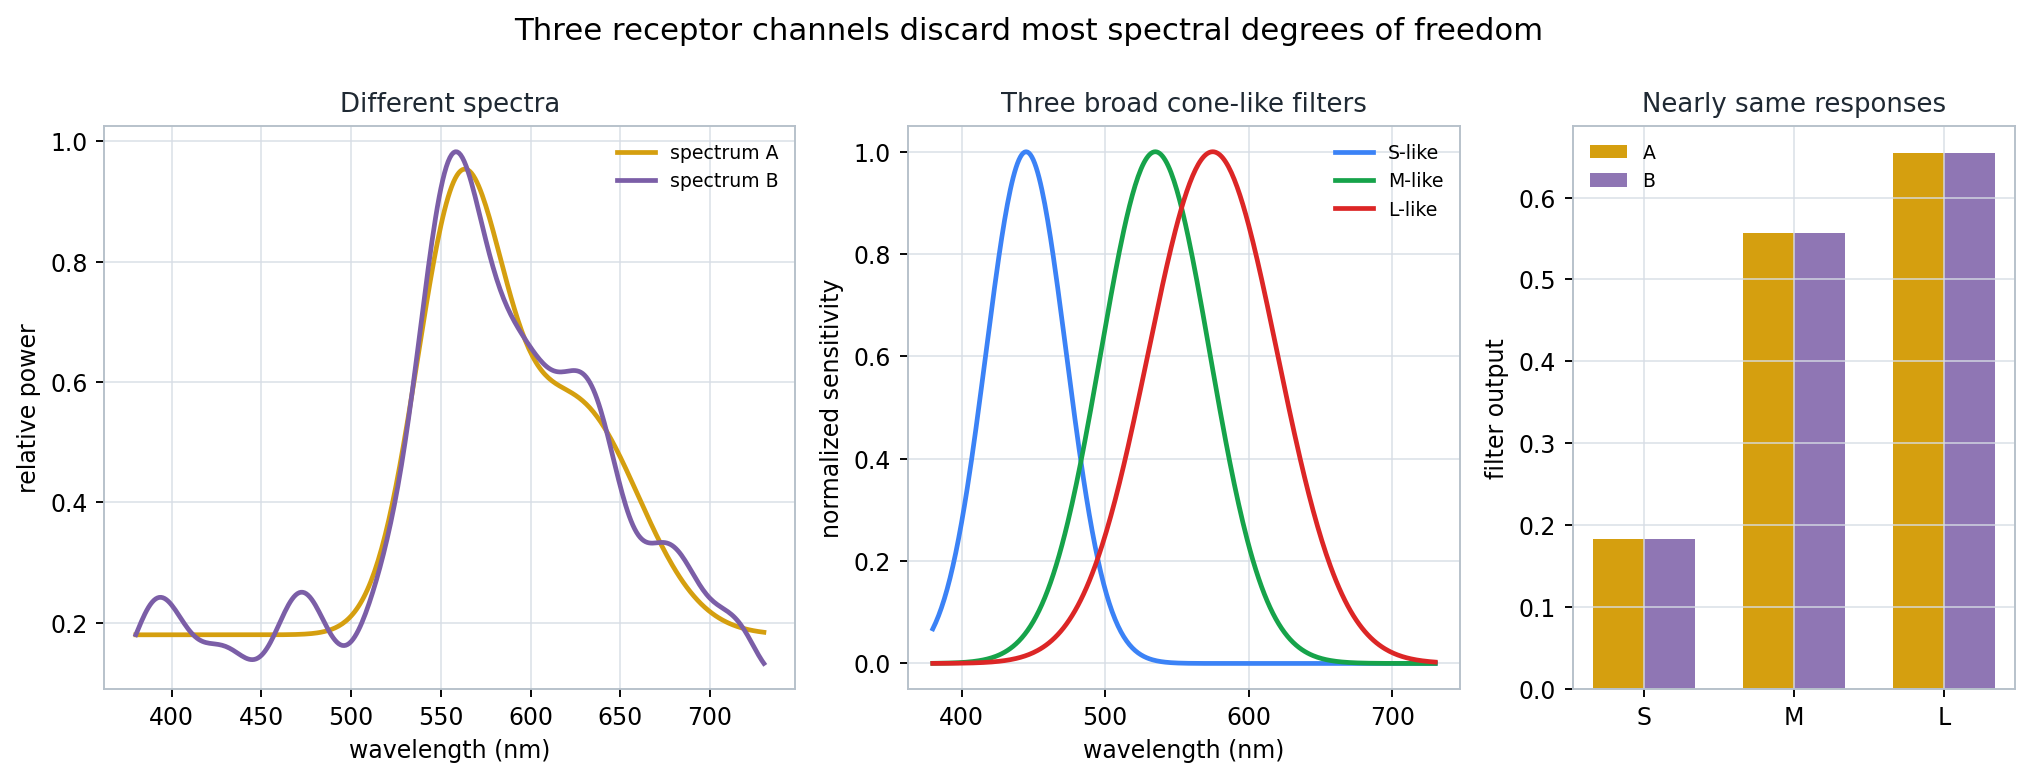

In [6]:
wavelength = np.linspace(380, 730, 351)
S = gaussian(wavelength, 445, 28)
M = gaussian(wavelength, 535, 38)
L = gaussian(wavelength, 575, 45)
cones = np.vstack([S / S.sum(), M / M.sum(), L / L.sum()])
spectrum_a = 0.18 + 0.70 * gaussian(wavelength, 560, 24) + 0.38 * gaussian(wavelength, 625, 35)
raw_variation = np.sin(2 * np.pi * (wavelength - 380) / 74) + 0.45 * np.sin(2 * np.pi * (wavelength - 380) / 41)
projection = cones.T @ np.linalg.solve(cones @ cones.T, cones @ raw_variation)
metamer_null = raw_variation - projection
metamer_null = metamer_null / np.max(np.abs(metamer_null))
positive_limits = (1.0 - spectrum_a[metamer_null > 0]) / metamer_null[metamer_null > 0]
negative_limits = (spectrum_a[metamer_null < 0] - 0.02) / (-metamer_null[metamer_null < 0])
scale = 0.72 * min(float(positive_limits.min()), float(negative_limits.min()))
spectrum_b = spectrum_a + scale * metamer_null
response_a = cones @ spectrum_a
response_b = cones @ spectrum_b
relative_response_error = np.linalg.norm(response_a - response_b) / np.linalg.norm(response_a)
spectral_difference = np.linalg.norm(spectrum_a - spectrum_b) / np.linalg.norm(spectrum_a)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), gridspec_kw={"width_ratios": [1.25, 1.0, 0.8]})
axes[0].plot(wavelength, spectrum_a, color=PALETTE["gold"], lw=2, label="spectrum A")
axes[0].plot(wavelength, spectrum_b, color=PALETTE["violet"], lw=2, label="spectrum B")
style_axis(axes[0], "Different spectra", xlabel="wavelength (nm)", ylabel="relative power")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(wavelength, cones[0] / cones[0].max(), color="#3b82f6", lw=2, label="S-like")
axes[1].plot(wavelength, cones[1] / cones[1].max(), color="#16a34a", lw=2, label="M-like")
axes[1].plot(wavelength, cones[2] / cones[2].max(), color="#dc2626", lw=2, label="L-like")
style_axis(axes[1], "Three broad cone-like filters", xlabel="wavelength (nm)", ylabel="normalized sensitivity")
axes[1].legend(frameon=False, fontsize=8)
xpos = np.arange(3)
width = 0.34
axes[2].bar(xpos - width/2, response_a, width, color=PALETTE["gold"], label="A")
axes[2].bar(xpos + width/2, response_b, width, color=PALETTE["violet"], alpha=0.85, label="B")
axes[2].set_xticks(xpos, labels=["S", "M", "L"])
style_axis(axes[2], "Nearly same responses", ylabel="filter output")
axes[2].legend(frameon=False, fontsize=8)
fig.suptitle("Three receptor channels discard most spectral degrees of freedom", y=1.03, fontsize=13)
metamer_path = save_fig(fig, "cone-metamer-spectral-compression.png")
validation["cone_metamer"] = {
    "relative_response_error": float(relative_response_error),
    "relative_spectral_difference": float(spectral_difference),
    "spectrum_a_min": float(spectrum_a.min()),
    "spectrum_b_min": float(spectrum_b.min()),
    "spectrum_b_max": float(spectrum_b.max()),
}
metamer_checks = save_check(validation["cone_metamer"], "cone-metamer-checks.json")
display_artifact(metamer_path, width=900)
display_artifact(metamer_checks)

## 4. Spatial Vision Turns Cues Into Constraints

Depth and surface orientation are not directly written into the image. The chapter organizes spatial vision into cue families: oculomotor, binocular disparity, motion cues, and pictorial cues such as linear perspective, occlusion, shadows, texture gradients, and shading. Each cue is an inference rule with assumptions.

The next artifact keeps the rules explicit. Vergence depth and ground-plane declination have simple trigonometric checks. Texture slant uses foreshortening. Shading is shown as a surface-normal constraint under a fixed light direction. Shadow placement and T-junctions supply ordinal information rather than metric distance.

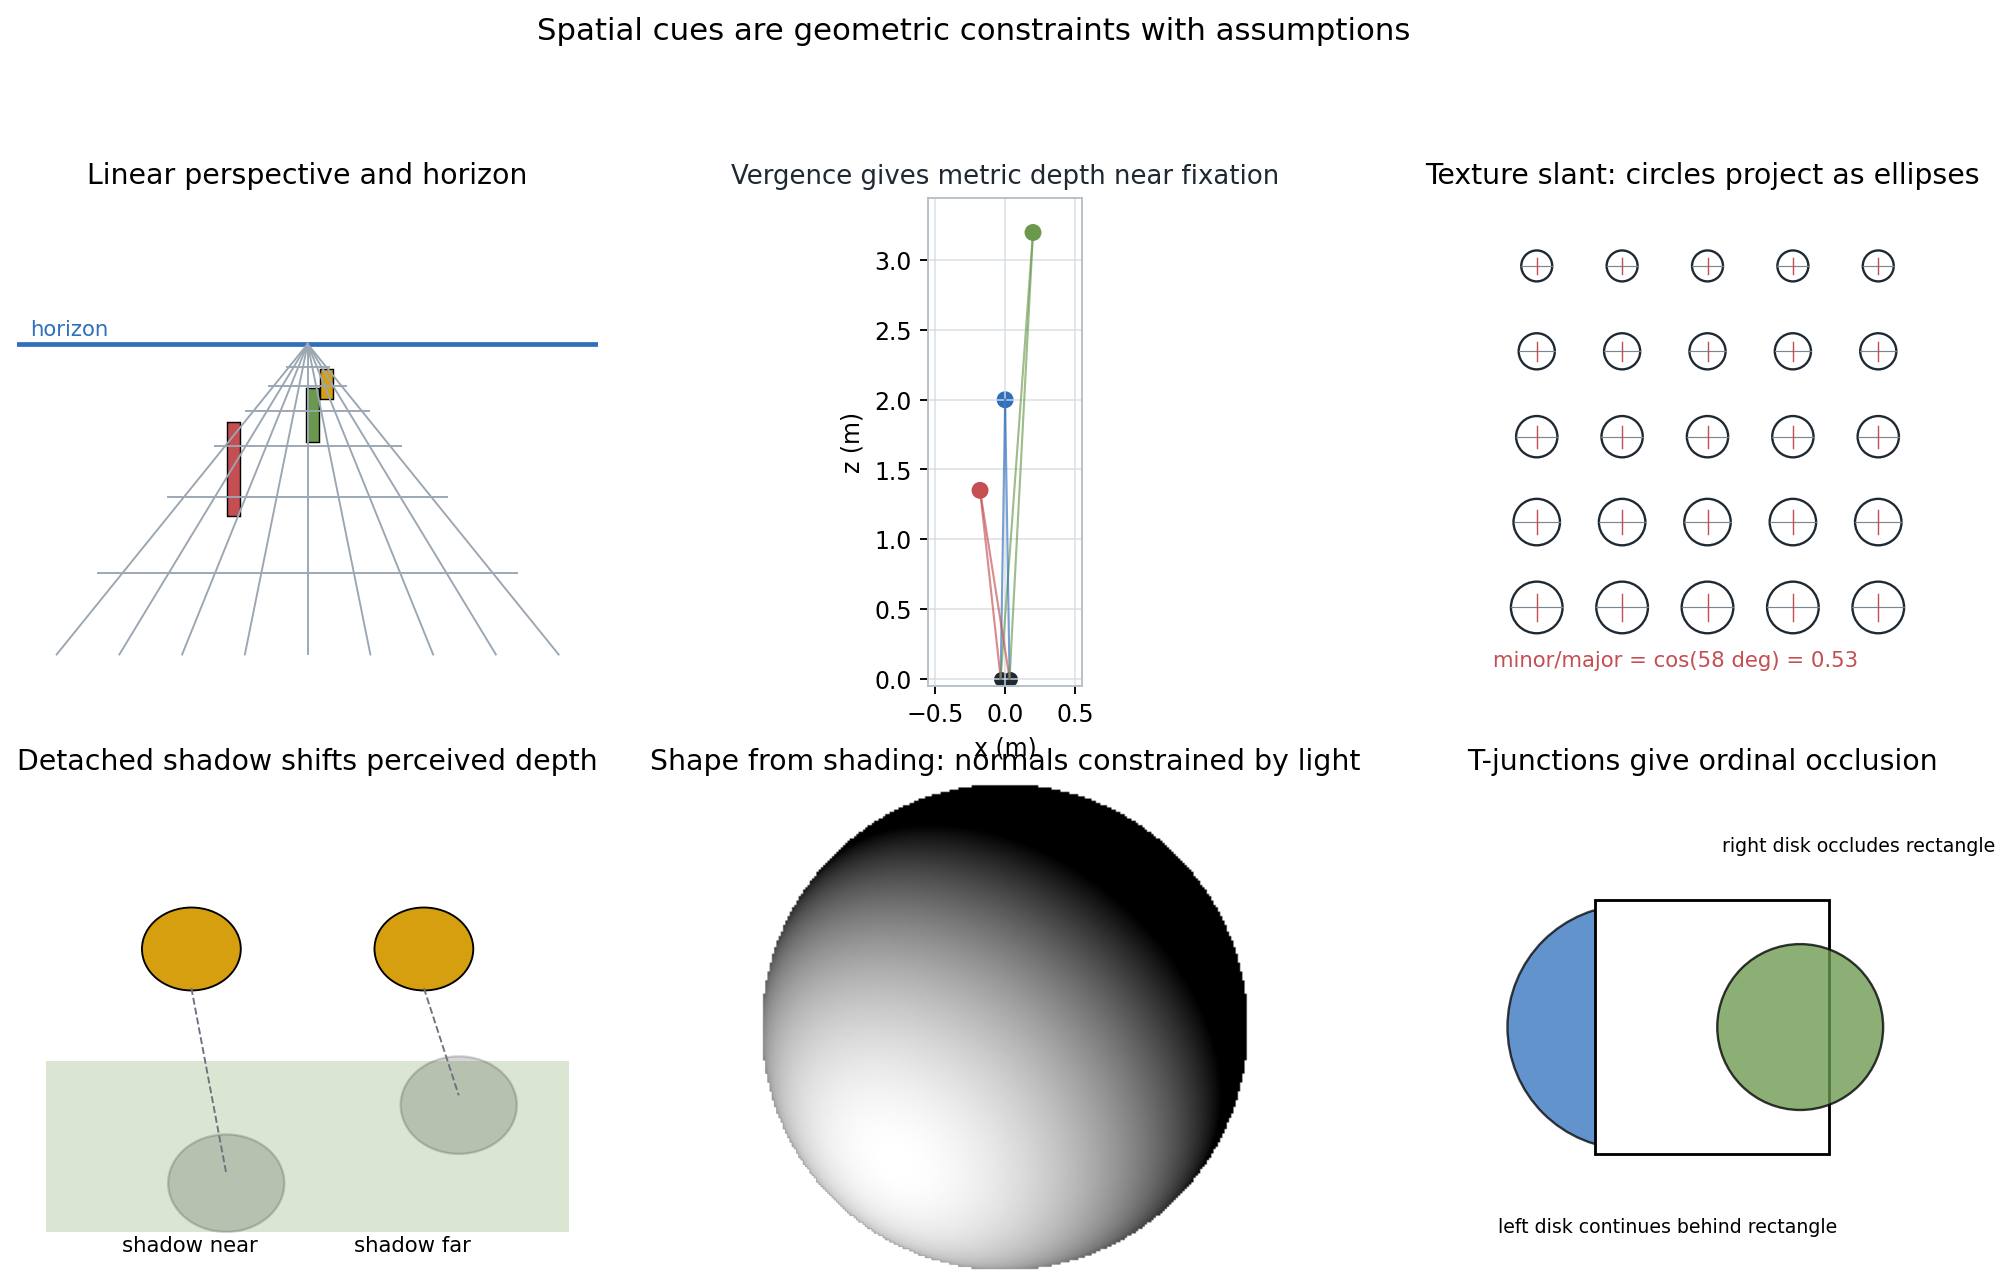

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.2))
ax = axes[0, 0]
ax.set_title("Linear perspective and horizon")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-0.05, 1.05)
ax.axis("off")
horizon_y = 0.72
ax.axhline(horizon_y, color=PALETTE["blue"], lw=2)
ax.text(-1.05, horizon_y + 0.02, "horizon", color=PALETTE["blue"], fontsize=9)
for x0 in np.linspace(-0.95, 0.95, 9):
    ax.plot([x0, 0], [0.02, horizon_y], color="#9aa6b2", lw=0.8)
for d in [1.2, 1.8, 2.7, 4.1, 6.5, 12.0]:
    y = horizon_y - 0.62 / d
    ax.plot([-0.95 / d, 0.95 / d], [y, y], color="#9aa6b2", lw=0.8)
for x_obj, d, c in [(-0.45, 1.6, PALETTE["red"]), (0.05, 2.8, PALETTE["green"]), (0.36, 5.0, PALETTE["gold"])]:
    base_y = horizon_y - 0.62 / d
    height = 0.34 / d
    ax.add_patch(Rectangle((x_obj / d - 0.025, base_y), 0.05, height, facecolor=c, edgecolor="black", lw=0.6))

ax = axes[0, 1]
style_axis(ax, "Vergence gives metric depth near fixation", equal=True, xlabel="x (m)", ylabel="z (m)")
ipd = 0.064
fix_z = 2.0
near_z = 1.35
far_z = 3.2
left_eye = np.array([-ipd / 2, 0.0])
right_eye = np.array([ipd / 2, 0.0])
for eye in [left_eye, right_eye]:
    ax.scatter(*eye, color=PALETTE["ink"], s=28)
    for p, col in [(np.array([0.0, fix_z]), PALETTE["blue"]), (np.array([-0.18, near_z]), PALETTE["red"]), (np.array([0.2, far_z]), PALETTE["green"])]:
        ax.plot([eye[0], p[0]], [eye[1], p[1]], color=col, lw=0.9, alpha=0.65)
ax.scatter([0, -0.18, 0.2], [fix_z, near_z, far_z], color=[PALETTE["blue"], PALETTE["red"], PALETTE["green"]], s=38)
ax.set_xlim(-0.55, 0.55)
ax.set_ylim(-0.05, 3.45)
vergence_theta = math.atan((ipd / 2) / fix_z)
z_from_vergence = (ipd / 2) / math.tan(vergence_theta)

ax = axes[0, 2]
ax.set_title("Texture slant: circles project as ellipses")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
slant_deg = 58
ratio = math.cos(math.radians(slant_deg))
for y in np.linspace(0.16, 0.86, 5):
    for x0 in np.linspace(0.16, 0.86, 5):
        radius = 0.055 * (1.05 - 0.55 * y)
        ax.add_patch(Circle((x0, y), radius=radius, facecolor="none", edgecolor=PALETTE["ink"], lw=1.0))
        ax.plot([x0 - radius, x0 + radius], [y, y], color=PALETTE["gray"], lw=0.5)
        ax.plot([x0, x0], [y - radius * ratio, y + radius * ratio], color=PALETTE["red"], lw=0.6)
ax.text(0.07, 0.04, f"minor/major = cos({slant_deg} deg) = {ratio:.2f}", fontsize=9, color=PALETTE["red"])

ax = axes[1, 0]
ax.set_title("Detached shadow shifts perceived depth")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.add_patch(Rectangle((0.05, 0.08), 0.9, 0.35, facecolor="#dbe6d2", edgecolor="none"))
for x0, shadow_y, label in [(0.30, 0.18, "shadow near"), (0.70, 0.34, "shadow far")]:
    ax.add_patch(Circle((x0 + 0.06, shadow_y), 0.10, color="black", alpha=0.16))
    ax.add_patch(Circle((x0, 0.66), 0.085, facecolor=PALETTE["gold"], edgecolor="black", lw=0.8))
    ax.plot([x0, x0 + 0.06], [0.58, shadow_y + 0.02], color="#6b7280", lw=0.8, ls="--")
    ax.text(x0 - 0.12, 0.04, label, fontsize=9)

ax = axes[1, 1]
N = 220
yg, xg = np.mgrid[-1:1:complex(N), -1:1:complex(N)]
mask = xg**2 + yg**2 <= 1
zg = np.zeros_like(xg)
zg[mask] = np.sqrt(1 - xg[mask]**2 - yg[mask]**2)
light = np.array([-0.45, -0.55, 0.70])
light = light / np.linalg.norm(light)
shade = np.zeros_like(xg) + np.nan
shade[mask] = np.clip(xg[mask] * light[0] + yg[mask] * light[1] + zg[mask] * light[2], 0, 1)
ax.imshow(shade, cmap="gray", origin="lower", vmin=0, vmax=1)
ax.set_title("Shape from shading: normals constrained by light")
ax.axis("off")

ax = axes[1, 2]
ax.set_title("T-junctions give ordinal occlusion")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
ax.add_patch(Circle((0.35, 0.5), 0.25, facecolor=PALETTE["blue"], alpha=0.75, edgecolor="black"))
ax.add_patch(Rectangle((0.28, 0.24), 0.48, 0.52, facecolor="white", edgecolor="black", lw=1.2))
ax.add_patch(Circle((0.70, 0.5), 0.17, facecolor=PALETTE["green"], alpha=0.78, edgecolor="black"))
ax.text(0.08, 0.08, "left disk continues behind rectangle", fontsize=8)
ax.text(0.54, 0.86, "right disk occludes rectangle", fontsize=8)

fig.suptitle("Spatial cues are geometric constraints with assumptions", y=1.01, fontsize=13)
depth_path = save_fig(fig, "spatial-depth-cue-geometry.png")
eye_height = 1.62
theta_deg = np.array([5, 10, 20, 35], dtype=float)
d_declination = eye_height / np.tan(np.deg2rad(theta_deg))
cue_rows = []
for theta, dist in zip(theta_deg, d_declination):
    cue_rows.append({"cue": "ground_declination", "angle_deg": float(theta), "distance_m": float(dist)})
for angle_deg in [0.75, 1.0, 1.5, 2.0]:
    theta = math.radians(angle_deg)
    cue_rows.append({"cue": "vergence", "angle_deg": float(angle_deg), "distance_m": float((ipd / 2) / math.tan(theta))})
cue_rows.append({"cue": "texture_foreshortening", "angle_deg": float(slant_deg), "distance_m": float(ratio)})
depth_table = save_table(cue_rows, "depth-cue-validation.csv")
validation["spatial_depth"] = {
    "vergence_depth_residual": float(abs(z_from_vergence - fix_z)),
    "declination_distance_decreases_with_angle": bool(np.all(np.diff(d_declination) < 0)),
    "texture_minor_major_ratio": float(ratio),
    "shading_valid_pixel_fraction": float(np.isfinite(shade).mean()),
    "cue_rows": len(cue_rows),
}
depth_checks = save_check(validation["spatial_depth"], "spatial-depth-cue-checks.json")
display_artifact(depth_path, width=900)
display_artifact(depth_table)

## 5. Motion Perception: Flow, Stability, and Aliasing

Motion is both a signal and a nuisance. Retinal motion can reveal heading, object motion, boundaries, and time-to-contact. It can also be created by eye movements, frame sampling, and temporal aliasing. The chapter's wagon-wheel example is especially important for animation and real-time rendering: apparent motion is produced by samples, not by continuous movement.

The artifact below compares analytic optic-flow fields with sampled wheel motion. The check records two invariants: forward optic flow is zero at the focus of expansion, and doubling both scene scale and speed leaves translational flow unchanged.

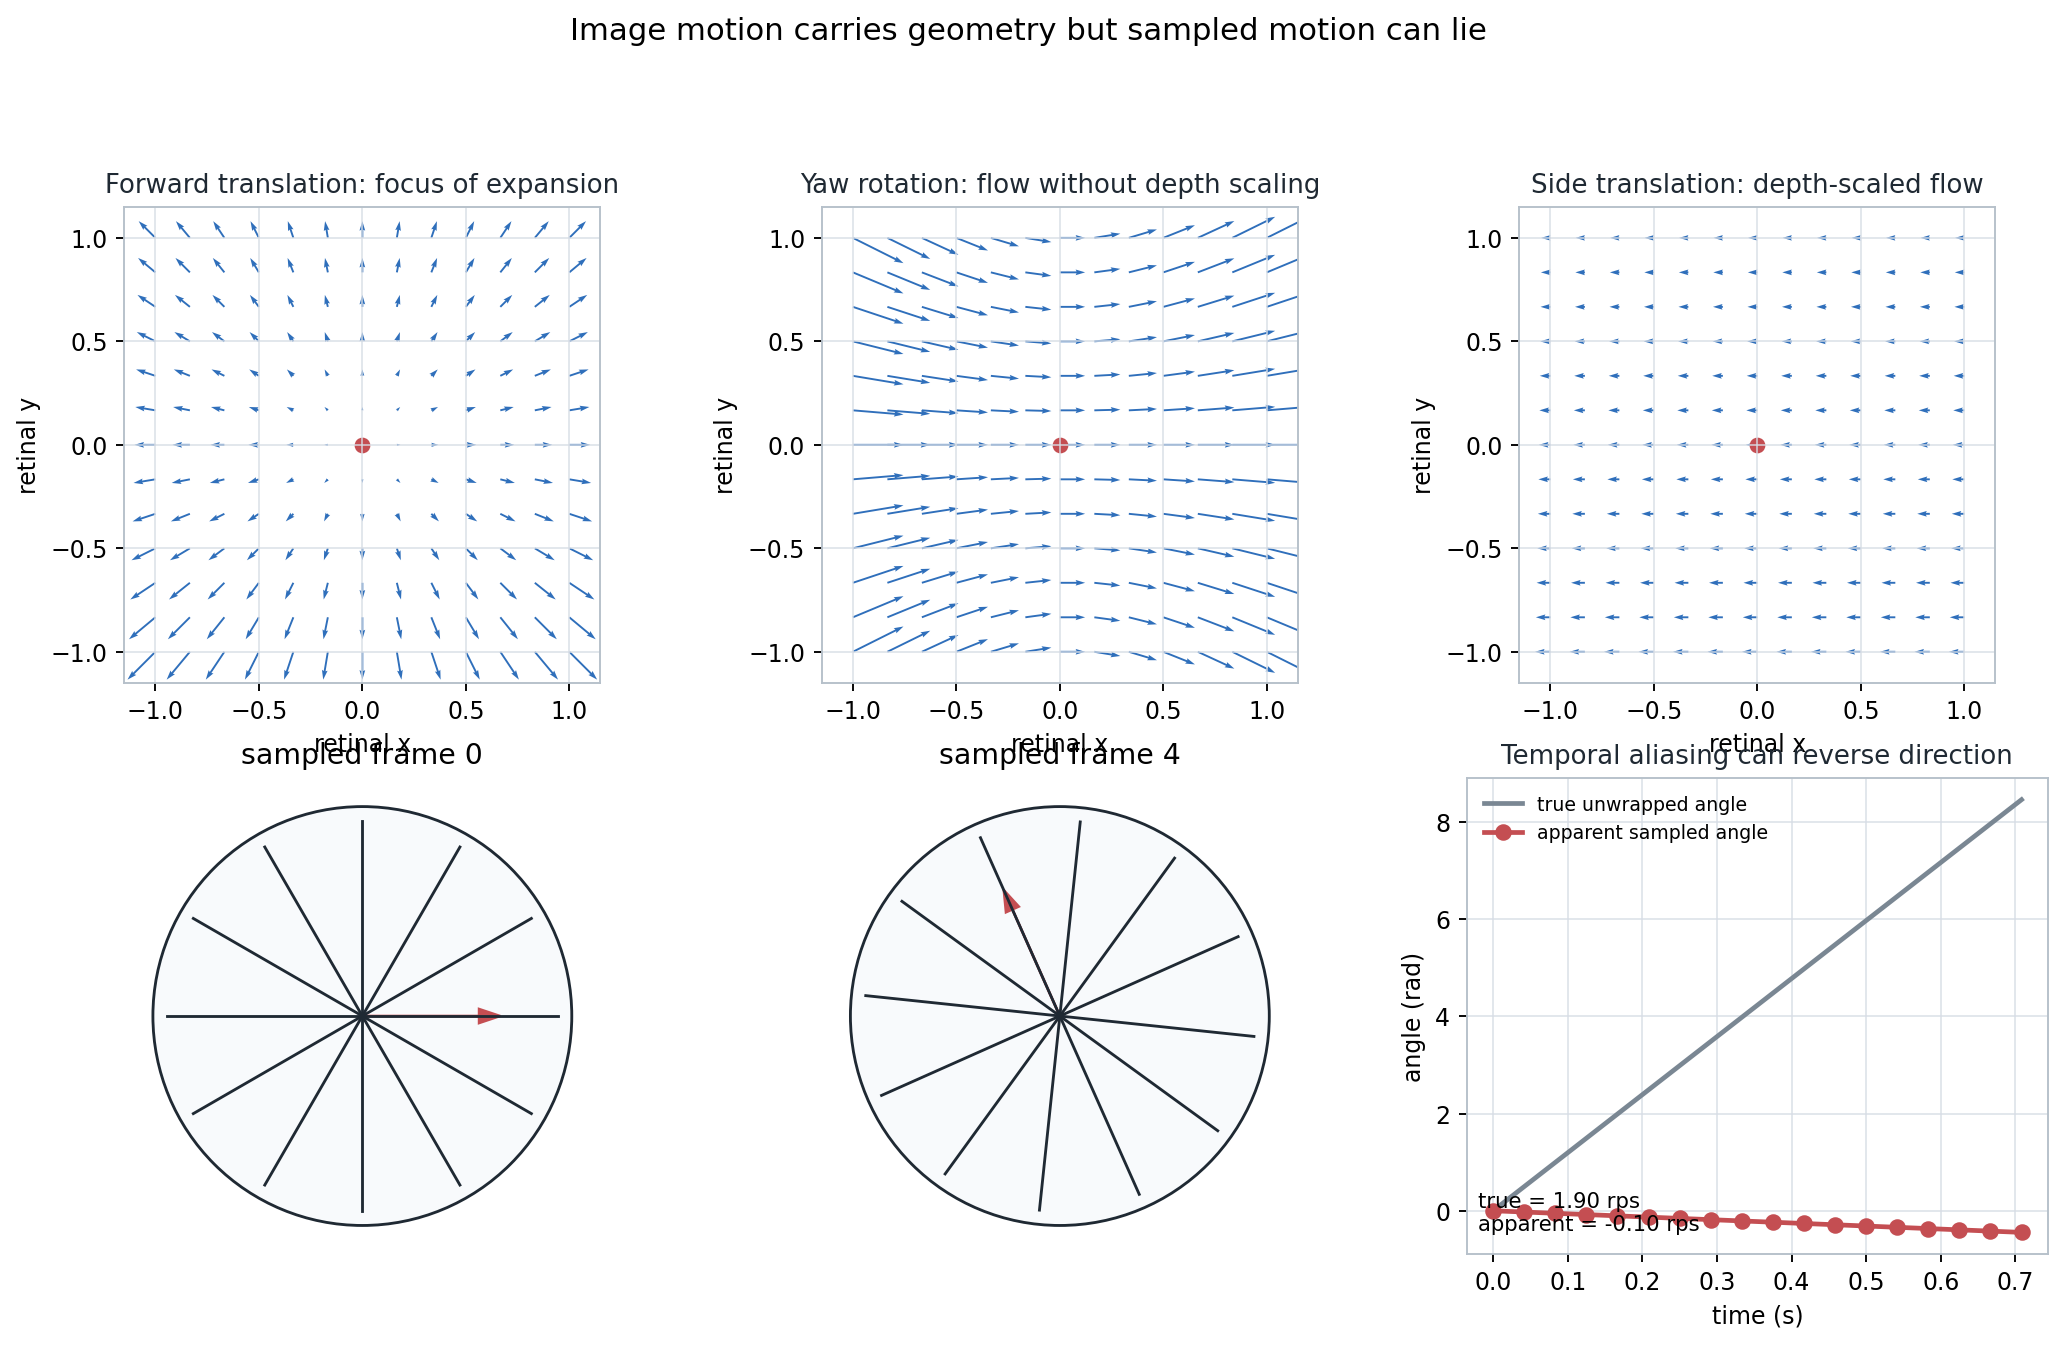

In [8]:
grid = np.linspace(-1.0, 1.0, 13)
X, Y = np.meshgrid(grid, grid)
Z = 2.2 + 0.55 * Y
forward_u = X / Z
forward_v = Y / Z
rotation_u = 0.55 * (1 + X**2)
rotation_v = 0.55 * X * Y
lateral_u = -0.55 / Z
lateral_v = np.zeros_like(lateral_u)

spokes = 12
frame_rate = 24.0
true_rps = 1.90
frames = np.arange(0, 18)
spoke_period = 2 * np.pi / spokes
true_step = 2 * np.pi * true_rps / frame_rate
apparent_step = ((true_step + spoke_period / 2) % spoke_period) - spoke_period / 2
apparent_rps = apparent_step * frame_rate / (2 * np.pi)
true_orientation = frames * true_step
apparent_orientation = frames * apparent_step

fig, axes = plt.subplots(2, 3, figsize=(15, 8.0))
for ax, (u, v, title) in zip(axes[0], [
    (forward_u, forward_v, "Forward translation: focus of expansion"),
    (rotation_u, rotation_v, "Yaw rotation: flow without depth scaling"),
    (lateral_u, lateral_v, "Side translation: depth-scaled flow"),
]):
    ax.quiver(X, Y, u, v, color=PALETTE["blue"], angles="xy", scale_units="xy", scale=4.5, width=0.004)
    ax.scatter([0], [0], s=32, color=PALETTE["red"])
    style_axis(ax, title, equal=True, xlabel="retinal x", ylabel="retinal y")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)

for i, ax in enumerate(axes[1, :2].ravel()):
    f = i * 4
    angle = true_orientation[f]
    ax.set_title(f"sampled frame {f}")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.add_patch(Circle((0, 0), 0.88, facecolor="#f8fafc", edgecolor=PALETTE["ink"], lw=1.2))
    for s in range(spokes):
        a = angle + s * spoke_period
        ax.plot([0, 0.82 * math.cos(a)], [0, 0.82 * math.sin(a)], color=PALETTE["ink"], lw=1.2)
    ax.arrow(0, 0, 0.58 * math.cos(angle), 0.58 * math.sin(angle), color=PALETTE["red"], head_width=0.06, length_includes_head=True)

ax = axes[1, 2]
ax.plot(frames / frame_rate, np.unwrap(true_orientation), color=PALETTE["gray"], lw=2, label="true unwrapped angle")
ax.plot(frames / frame_rate, apparent_orientation, color=PALETTE["red"], lw=2, marker="o", label="apparent sampled angle")
style_axis(ax, "Temporal aliasing can reverse direction", xlabel="time (s)", ylabel="angle (rad)")
ax.legend(frameon=False, fontsize=8)
ax.text(0.02, 0.05, f"true = {true_rps:.2f} rps\napparent = {apparent_rps:.2f} rps", transform=ax.transAxes, fontsize=9)
fig.suptitle("Image motion carries geometry but sampled motion can lie", y=1.02, fontsize=13)
motion_path = save_fig(fig, "motion-optic-flow-temporal-aliasing.png")
flow_scaled_original = 1.4 / 2.8
flow_scaled_double = (2 * 1.4) / (2 * 2.8)
validation["motion"] = {
    "forward_flow_at_foe_norm": float(np.hypot(forward_u[6, 6], forward_v[6, 6])),
    "scale_speed_flow_difference": float(abs(flow_scaled_original - flow_scaled_double)),
    "true_wheel_rps": float(true_rps),
    "apparent_wheel_rps": float(apparent_rps),
    "alias_reverses_direction": bool(apparent_rps < 0 < true_rps),
}
motion_checks = save_check(validation["motion"], "motion-flow-aliasing-checks.json")
display_artifact(motion_path, width=900)
display_artifact(motion_checks)

## 6. Object Perception: Group First, Then Identify

Object recognition is not a single template lookup. The chapter separates two jobs: grouping image evidence into likely objects or surfaces, and then identifying the grouped structure using templates, structural descriptions, or invariant features. The grouping displays below use the same primitive marks but alter proximity and similarity. The matching panel uses OpenCV on a synthetic scene so the hit location can be audited.

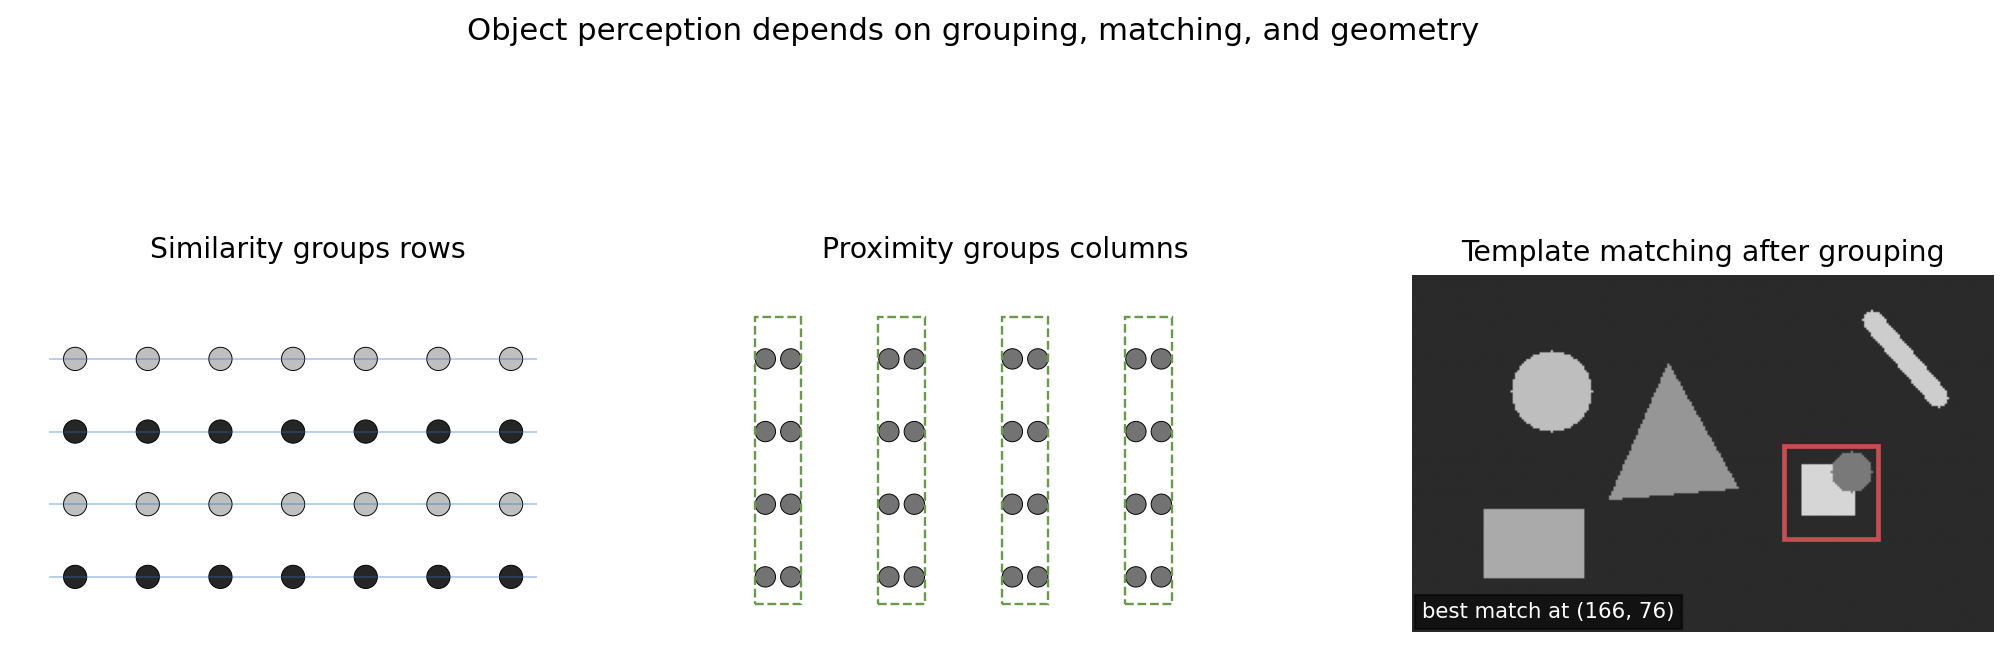

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
ax = axes[0]
ax.set_title("Similarity groups rows")
ax.set_xlim(0, 8)
ax.set_ylim(0, 5)
ax.set_aspect("equal")
ax.axis("off")
for row in range(4):
    for col in range(7):
        color_value = 0.15 if row % 2 == 0 else 0.75
        ax.add_patch(Circle((col + 0.8, row + 0.8), 0.16, facecolor=str(color_value), edgecolor="black", lw=0.4))
for row in [0.8, 1.8, 2.8, 3.8]:
    ax.plot([0.45, 7.15], [row, row], color=PALETTE["blue"], lw=0.8, alpha=0.35)

ax = axes[1]
ax.set_title("Proximity groups columns")
ax.set_xlim(0, 8)
ax.set_ylim(0, 5)
ax.set_aspect("equal")
ax.axis("off")
x_positions = [0.7, 1.05, 2.4, 2.75, 4.1, 4.45, 5.8, 6.15]
for x0 in x_positions:
    for row in range(4):
        ax.add_patch(Circle((x0, row + 0.8), 0.14, facecolor="0.45", edgecolor="black", lw=0.4))
for x0 in [0.875, 2.575, 4.275, 5.975]:
    ax.add_patch(Rectangle((x0 - 0.32, 0.42), 0.64, 3.95, facecolor="none", edgecolor=PALETTE["green"], lw=1.0, ls="--"))

scene = np.full((160, 260), 42, dtype=np.uint8)
template = np.full((42, 42), 42, dtype=np.uint8)
cv2.rectangle(template, (8, 9), (31, 31), 214, -1)
cv2.circle(template, (30, 12), 9, 122, -1)
true_xy = (166, 76)
y0, x0 = true_xy[1], true_xy[0]
scene[y0:y0 + template.shape[0], x0:x0 + template.shape[1]] = template
cv2.circle(scene, (62, 52), 18, 190, -1)
cv2.rectangle(scene, (32, 105), (76, 135), 170, -1)
pts = np.array([[114, 40], [145, 95], [88, 100]], np.int32)
cv2.fillPoly(scene, [pts], 150)
cv2.line(scene, (205, 20), (235, 55), 205, 7)
result = cv2.matchTemplate(scene, template, cv2.TM_SQDIFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
best_x, best_y = min_loc
ax = axes[2]
ax.set_title("Template matching after grouping")
ax.imshow(scene, cmap="gray", vmin=0, vmax=255)
ax.add_patch(Rectangle((best_x, best_y), template.shape[1], template.shape[0], facecolor="none", edgecolor=PALETTE["red"], lw=2))
ax.axis("off")
ax.text(4, 153, f"best match at ({best_x}, {best_y})", color="white", fontsize=9, bbox={"facecolor": "black", "alpha": 0.55, "pad": 3})
fig.suptitle("Object perception depends on grouping, matching, and geometry", y=1.03, fontsize=13)
object_path = save_fig(fig, "object-grouping-template-matching.png")
validation["object_perception"] = {
    "template_true_x": int(true_xy[0]),
    "template_true_y": int(true_xy[1]),
    "template_best_x": int(best_x),
    "template_best_y": int(best_y),
    "template_match_error_pixels": float(np.hypot(best_x - true_xy[0], best_y - true_xy[1])),
    "template_min_score": float(min_val),
    "proximity_panel_groups": 4,
}
object_checks = save_check(validation["object_perception"], "object-perception-checks.json")
display_artifact(object_path, width=900)
display_artifact(object_checks)

## 7. Picture Perception: The Display Has Its Own Geometry

A rendered perspective image is geometrically consistent with a particular frustum and viewpoint. A viewer looking at the display from a different position receives different visual angles at the picture border, so the pictorial cues no longer match the projection used to make the image. Human vision compensates somewhat, which is why pictures remain useful from many seats, but the mismatch matters for large screens, VR, CAVEs, simulators, and design review.

The interactive HTML artifact below compares the render frustum with three actual viewing distances. The numeric check records the border visual angle for each case.

In [10]:
screen_width = 2.0
render_fov_deg = 60.0
correct_distance = (screen_width / 2) / math.tan(math.radians(render_fov_deg / 2))
viewer_cases = [
    ("too close", 0.62 * correct_distance, PALETTE["red"]),
    ("matched", correct_distance, PALETTE["green"]),
    ("too far", 1.65 * correct_distance, PALETTE["blue"]),
]
fig = go.Figure()
fig.add_trace(go.Scatter(x=[-screen_width/2, screen_width/2], y=[0, 0], mode="lines", line={"color": "black", "width": 5}, name="display surface"))
fig.add_trace(go.Scatter(x=[-screen_width/2, 0, screen_width/2], y=[0, correct_distance, 0], mode="lines", line={"color": "rgba(80,80,80,0.45)", "dash": "dash"}, name="render frustum"))
for name, dist, col in viewer_cases:
    yv = -dist
    fig.add_trace(go.Scatter(x=[0], y=[yv], mode="markers+text", marker={"size": 10, "color": col}, text=[name], textposition="bottom center", name=f"viewer: {name}"))
    fig.add_trace(go.Scatter(x=[0, -screen_width/2, None, 0, screen_width/2], y=[yv, 0, None, yv, 0], mode="lines", line={"color": col, "width": 2}, name=f"rays: {name}"))
    actual = math.degrees(2 * math.atan((screen_width / 2) / dist))
    fig.add_annotation(x=0.78, y=yv / 2, text=f"{actual:.1f} deg", showarrow=False, font={"color": col})
fig.update_layout(
    title="Picture geometry depends on where the display is viewed from",
    xaxis_title="screen x coordinate",
    yaxis_title="depth from display plane",
    width=850,
    height=540,
    template="plotly_white",
    yaxis={"scaleanchor": "x", "scaleratio": 1},
    legend={"orientation": "h", "y": -0.12},
)
picture_html = save_plotly_html(fig, TOPIC, "picture-space-viewpoint-mismatch.html", include_plotlyjs=True)
remember(picture_html, html_paths)
view_rows = []
for name, dist, _ in viewer_cases:
    actual_fov = math.degrees(2 * math.atan((screen_width / 2) / dist))
    view_rows.append({"viewer_case": name, "distance_to_screen": float(dist), "border_visual_angle_deg": float(actual_fov), "fov_error_deg": float(actual_fov - render_fov_deg)})
picture_table = save_table(view_rows, "picture-viewing-geometry.csv")
validation["picture_perception"] = {
    "render_fov_deg": render_fov_deg,
    "correct_distance": float(correct_distance),
    "too_close_fov_gt_render": bool(view_rows[0]["border_visual_angle_deg"] > render_fov_deg),
    "too_far_fov_lt_render": bool(view_rows[2]["border_visual_angle_deg"] < render_fov_deg),
    "matched_fov_error_abs": float(abs(view_rows[1]["fov_error_deg"])),
}
picture_checks = save_check(validation["picture_perception"], "picture-perception-viewing-checks.json")
display_artifact(picture_html, width="100%", height=520)
display_artifact(picture_table)

## Applied lab: A Perception Stress Matrix for Graphics

A practical graphics system can use the chapter as a test plan. Each row below maps a perceptual risk to a synthetic stimulus, a measurable failure signal, and a renderer or UI decision it informs. The rows are deliberately synthetic so they can be regenerated in continuous integration without depending on copyrighted images or manual viewing conditions.

In [11]:
stress_rows = [
    {"risk": "low-contrast detail disappears", "synthetic_test": "frequency-by-contrast grating", "failure_signal": "contrast threshold too high for target viewing distance", "graphics_decision": "increase contrast, reduce fine detail, or change display mapping"},
    {"risk": "same RGB appears inconsistent", "synthetic_test": "equal center swatches in different surrounds", "failure_signal": "local pixel equality conflicts with judged lightness/color", "graphics_decision": "preview in context and avoid isolated color picking"},
    {"risk": "depth cues disagree", "synthetic_test": "ground plane plus familiar-size and shadow manipulations", "failure_signal": "metric depth cue and ordinal cue imply different order", "graphics_decision": "align shadows, horizon, object scale, and stereo"},
    {"risk": "animation aliases", "synthetic_test": "rotating periodic wheel sampled at frame rate", "failure_signal": "apparent angular velocity changes sign", "graphics_decision": "raise sample rate, add motion blur, or avoid high-frequency spokes"},
    {"risk": "object state is hard to find", "synthetic_test": "pop-out vs conjunction-search display", "failure_signal": "target requires serial search", "graphics_decision": "encode urgent states with a single strong feature"},
    {"risk": "perspective looks wrong on display", "synthetic_test": "viewing-distance/frustum mismatch", "failure_signal": "actual screen visual angle differs from render frustum", "graphics_decision": "control viewer position or adjust projection"},
]
stress_table = save_table(stress_rows, "perception-design-stress-tests.csv")
pd.DataFrame(stress_rows)

,risk,synthetic_test,failure_signal,graphics_decision
0,low-contrast detail disappears,frequency-by-contrast grating,contrast threshold too high for target viewing...,"increase contrast, reduce fine detail, or chan..."
1,same RGB appears inconsistent,equal center swatches in different surrounds,local pixel equality conflicts with judged lig...,preview in context and avoid isolated color pi...
2,depth cues disagree,ground plane plus familiar-size and shadow man...,metric depth cue and ordinal cue imply differe...,"align shadows, horizon, object scale, and stereo"
3,animation aliases,rotating periodic wheel sampled at frame rate,apparent angular velocity changes sign,"raise sample rate, add motion blur, or avoid h..."
4,object state is hard to find,pop-out vs conjunction-search display,target requires serial search,encode urgent states with a single strong feature
5,perspective looks wrong on display,viewing-distance/frustum mismatch,actual screen visual angle differs from render...,control viewer position or adjust projection


## Sanity checks

The checks below are not a substitute for human viewing, but they catch the mistakes that make perception notebooks untrustworthy: missing artifacts, blank figures, stale paths, equality claims that are false, and geometry formulas that no longer match the visuals.

In [12]:
all_artifacts = [*figure_paths, *html_paths, *check_paths, *table_paths]
artifact_records = assert_artifacts(all_artifacts)
image_records = [assert_nonblank_image(path) for path in figure_paths]
assert validation["contrast_sensitivity"]["visibility_cells_above_threshold"] > 0
assert validation["context_invariants"]["gray_center_difference"] == 0.0
assert validation["context_invariants"]["rgb_center_difference"] == 0.0
assert validation["context_invariants"]["lab_center_delta_e"] < 1e-12
assert validation["cone_metamer"]["relative_response_error"] < 1e-12
assert validation["cone_metamer"]["relative_spectral_difference"] > 0.05
assert validation["spatial_depth"]["vergence_depth_residual"] < 1e-12
assert validation["spatial_depth"]["declination_distance_decreases_with_angle"]
assert validation["motion"]["forward_flow_at_foe_norm"] < 1e-12
assert validation["motion"]["scale_speed_flow_difference"] < 1e-12
assert validation["motion"]["alias_reverses_direction"]
assert validation["object_perception"]["template_match_error_pixels"] == 0.0
assert validation["picture_perception"]["too_close_fov_gt_render"]
assert validation["picture_perception"]["too_far_fov_lt_render"]
assert validation["picture_perception"]["matched_fov_error_abs"] < 1e-9
final_report = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": {"printed_pages": PRINTED_PAGES, "pdf_pages": PDF_PAGES},
    "figures": [book_relative(path) for path in figure_paths],
    "html": [book_relative(path) for path in html_paths],
    "checks": [book_relative(path) for path in check_paths],
    "tables": [book_relative(path) for path in table_paths],
    "artifact_count_before_final_report": len(all_artifacts),
    "nonblank_images": len(image_records),
    "validation": validation,
}
final_path = save_json(final_report, TOPIC, "final-sanity.json")
final_records = assert_artifacts([final_path])
display_artifact(final_path)
{"artifact_records": artifact_records + final_records, "image_records": image_records}

{'artifact_records': [{'path': 'artifacts/chapter-19/figures/contrast-sensitivity-adaptation-field.png',
   'bytes': 182655},
  {'path': 'artifacts/chapter-19/figures/lightness-color-context-invariants.png',
   'bytes': 155276},
  {'path': 'artifacts/chapter-19/figures/cone-metamer-spectral-compression.png',
   'bytes': 156337},
  {'path': 'artifacts/chapter-19/figures/spatial-depth-cue-geometry.png',
   'bytes': 271907},
  {'path': 'artifacts/chapter-19/figures/motion-optic-flow-temporal-aliasing.png',
   'bytes': 309610},
  {'path': 'artifacts/chapter-19/figures/object-grouping-template-matching.png',
   'bytes': 122184},
  {'path': 'artifacts/chapter-19/html/picture-space-viewpoint-mismatch.html',
   'bytes': 4855839},
  {'path': 'artifacts/chapter-19/checks/contrast-sensitivity-checks.json',
   'bytes': 233},
  {'path': 'artifacts/chapter-19/checks/perceptual-context-invariants.json',
   'bytes': 247},
  {'path': 'artifacts/chapter-19/checks/cone-metamer-checks.json',
   'bytes': 2

## Takeaways

Perception is not a final cosmetic stage after rendering. It is part of the graphics contract. The same pixels can be interpreted differently when their context changes; different spectra can collapse to the same cone responses; depth cues can agree, conflict, or provide only ordinal order; sampled motion can move backward; and a perspective picture has a viewing geometry whether or not the application controls it.

The practical lesson is to test rendered output with perceptual stimuli, not just with pixel equality. Pixel tests are still useful, but Chapter 19 explains why graphics systems also need contrast checks, context previews, depth-cue audits, motion sampling tests, object-search tests, and viewing-geometry checks.